## Portfolio Construction
- The first portfolio is what's known as a "Barbell" configuaration. The concept was pioneered by Nassim Nicholas Talib as a way to capture upside during volatile markets while nearly eliminating downside risk.
  * 95% save/5% convex tail-risk
  * IEF or TLT as core treasury exposure,
  * Direct 10-year Treasury notes via Treasury Direct
    * For this portfolio, I will pull from 'TBLL'
  * The 5% risk exposure can be from any call option, but for this    we'll use the VIX volatility index to track large market swings
    * This will mirror large market downturns


In [1]:
import numpy as np
import pandas as pd
import tidyfinance as tf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Tidyfinance to pull financial information from individual tickers

barbell = tf.download_data(
    domain="stock_prices",
    symbols=["TBLL", "^VIX"],
    start_date="2000-01-01",
    end_date="2026-05-26"
)
barbell.head().round(3)

,symbol,date,volume,open,low,high,close,adjusted_close
0,TBLL,2017-01-23,0.0,105.38,105.38,105.38,105.38,84.581
1,TBLL,2017-01-24,0.0,105.38,105.38,105.38,105.38,84.581
2,TBLL,2017-01-25,0.0,105.38,105.38,105.38,105.38,84.581
3,TBLL,2017-01-26,0.0,105.38,105.38,105.38,105.38,84.581
4,TBLL,2017-01-27,0.0,105.38,105.38,105.38,105.38,84.581


In [2]:
barbell_close_price = barbell.pivot(
    index='date',
    columns='symbol',
    values='close'
)
barbell_close_price.tail().round(4)

symbol,TBLL,^VIX
date,,
2026-05-19,105.47,18.06
2026-05-20,105.49,17.44
2026-05-21,105.50,16.76
2026-05-22,105.52,16.70
2026-05-25,NaN,16.59


/tmp/ipykernel_403540/227115393.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = barbell_close_price.pct_change().dropna()


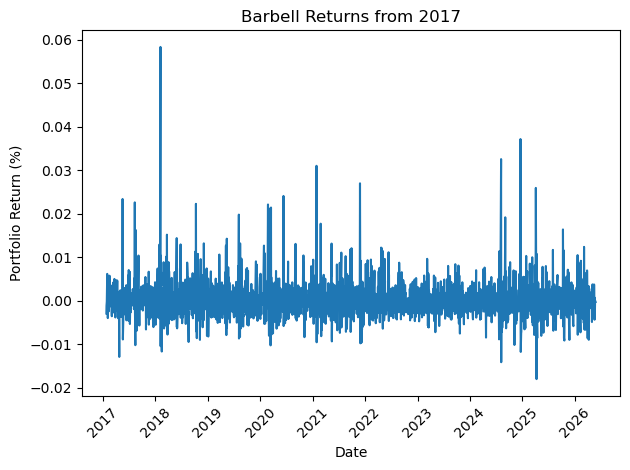

The Sharpe Ratio for the barbell portfolio
comes to 0.04


In [3]:
returns = barbell_close_price.pct_change().dropna()

cov_matrix = returns.cov()

weights = np.array([0.95, 0.05])   # same order as columns
portfolio_returns = returns.dot(weights)
sharpe = portfolio_returns.mean() /(portfolio_returns.std())

returns['port_returns'] = portfolio_returns

sns.lineplot(data=returns, x='date', y='port_returns')
plt.xlabel('Date')
plt.ylabel('Portfolio Return (%)')
plt.title("Barbell Returns from 2017")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"The Sharpe Ratio for the barbell portfolio\ncomes to {sharpe.round(3)}")

## Second Portfolio
- Mega-Cap Tech(S&P and NASDAQ top weights)
  - This portfolio contains top tech companies that have large exposure in the major indexes. It is my prediction that this portfolio will have the most direct correlation with benchmarks
  - Composition includes
    * Apple
    * Microsoft
    * NVIDIA
    * Google
    * Amazon
    * Meta
    * Broadcom
    * Tesla

In [4]:
mega_cap = tf.download_data(
    domain="stock_prices",
    symbols=["AAPL", "MSFT", "NVDA", "AMZN","GOOG","META","AVGO","TSLA"],
    start_date="2000-01-01",
    end_date="2026-05-26"
)
mega_cap.head().round(3)

,symbol,date,volume,open,low,high,close,adjusted_close
0,AAPL,2000-01-03,535796800,0.936,0.908,1.004,0.999,0.838
1,AAPL,2000-01-04,512377600,0.967,0.903,0.988,0.915,0.767
2,AAPL,2000-01-05,778321600,0.926,0.920,0.987,0.929,0.778
3,AAPL,2000-01-06,767972800,0.948,0.848,0.955,0.848,0.711
4,AAPL,2000-01-07,460734400,0.862,0.853,0.902,0.888,0.745


In [5]:
mega_close_price = mega_cap.pivot(
    index='date',
    columns='symbol',
    values='close'
)
mega_close_price.tail().round(4)

symbol,AAPL,AMZN,AVGO,GOOG,META,MSFT,NVDA,TSLA
date,,,,,,,,
2026-05-18,297.84,264.86,420.71,393.11,611.21,423.54,222.32,409.99
2026-05-19,298.97,259.34,411.07,384.90,602.61,417.42,220.61,404.11
2026-05-20,302.25,265.01,417.76,384.90,605.06,421.06,223.47,417.26
2026-05-21,304.99,268.46,414.57,383.47,607.38,419.09,219.51,417.85
2026-05-22,308.82,266.32,414.14,379.38,610.26,418.57,215.33,426.01


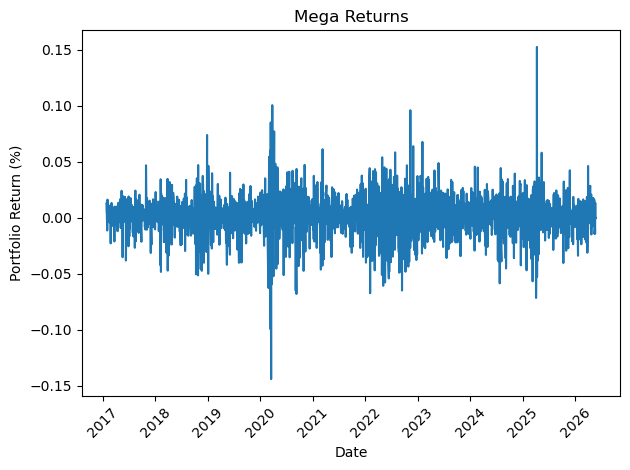

The Sharpe Ratio for the Mega-Cap Tech portfolio
comes to 0.084


In [6]:
mega_returns = mega_close_price.pct_change().dropna()

mega_cov_matrix = mega_returns.cov()

mega_weights = np.array([0.125,0.125,0.125,0.125,0.125,0.125,0.125,0.125])   # same order as columns
portfolio_returns = mega_returns.dot(mega_weights)
sharpe = portfolio_returns.mean() /(portfolio_returns.std())

returns['port_returns'] = portfolio_returns

sns.lineplot(data=returns, x='date', y='port_returns')
plt.xlabel('Date')
plt.ylabel('Portfolio Return (%)')
plt.title("Mega Returns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"The Sharpe Ratio for the Mega-Cap Tech portfolio\ncomes to {sharpe.round(3)}")

## Portfolio the Third
- This portfolio captures Energy sector exposure
  - Focuses mostly on Oil and large utilities
  - Some nuclear and some renewables
  - Oil and oilfield services indlude:
    * ExxonMobil
    * Chevron
    * ConocoPhillips
    * EOG Resources
    * Schlumberger
  - Electricity
    * NextEra Energy
    * Duke Energy
    * Constellation Energy
    * Southern Company
    * Dominion Energy

In [7]:
energy = tf.download_data(
    domain="stock_prices",
    symbols=["XOM", "CVX", "COP", "EOG","SLB","NEE","DUK","CEG","SO","D"],
    start_date="2000-01-01",
    end_date="2026-05-26"
)
energy.head().round(3)

,symbol,date,volume,open,low,high,close,adjusted_close
0,XOM,2000-01-03,13458200,39.750,38.938,40.375,39.156,17.026
1,XOM,2000-01-04,14510800,38.688,38.250,39.094,38.406,16.700
2,XOM,2000-01-05,17485000,39.000,38.906,40.875,40.500,17.610
3,XOM,2000-01-06,19461600,40.312,40.094,42.906,42.594,18.520
4,XOM,2000-01-07,16603800,42.969,42.000,43.125,42.469,18.466


In [8]:
energy_close_price = energy.pivot(
    index='date',
    columns='symbol',
    values='close'
)
energy_close_price.tail().round(4)

symbol,CEG,COP,CVX,D,DUK,EOG,NEE,SLB,SO,XOM
date,,,,,,,,,,
2026-05-18,262.00,124.54,196.12,67.56,122.84,142.99,89.04,57.15,93.71,160.49
2026-05-19,260.67,125.11,197.25,68.13,124.56,144.30,90.06,56.77,94.14,162.55
2026-05-20,281.26,122.36,191.33,67.73,123.81,141.63,88.27,57.28,93.62,156.28
2026-05-21,285.83,120.55,191.01,68.29,124.66,139.98,89.69,57.25,94.24,155.29
2026-05-22,294.07,120.46,191.43,67.67,125.67,141.22,88.55,57.28,94.55,154.92


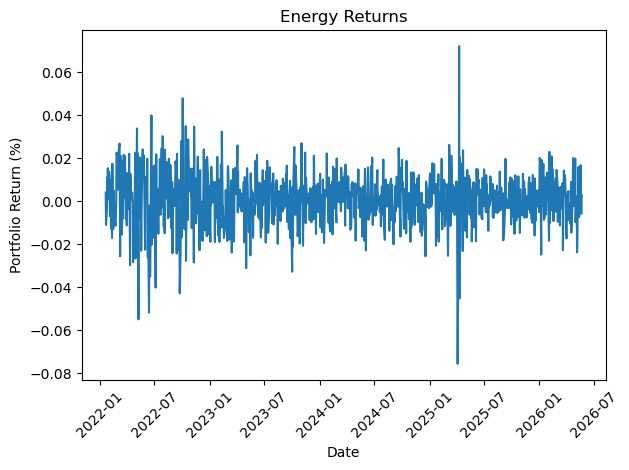

The Sharpe Ratio for the Energy portfolio
comes to 0.051


In [9]:
energy_returns = energy_close_price.pct_change().dropna()

energy_cov_matrix = energy_returns.cov()

energy_weights = np.array([0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1])   # same order as columns
energy_portfolio_returns = energy_returns.dot(energy_weights)
sharpe = energy_portfolio_returns.mean() /(energy_portfolio_returns.std())

returns['port_returns'] = energy_portfolio_returns

sns.lineplot(data=returns, x='date', y='port_returns')
plt.xlabel('Date')
plt.ylabel('Portfolio Return (%)')
plt.title("Energy Returns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"The Sharpe Ratio for the Energy portfolio\ncomes to {sharpe.round(3)}")

## Real Estate Investment Trusts
- Tracking how commercial real estate does during growth and downturn years by tracking the most diversified index
  - This is the Vanguard Real Estate ETF
    * VNQ

In [10]:
reit = tf.download_data(
    domain="stock_prices",
    symbols=["VNQ"],
    start_date="2000-01-01",
    end_date="2026-05-26"
)
reit.head().round(3)

,symbol,date,volume,open,low,high,close,adjusted_close
0,VNQ,2004-09-29,205800,49.85,49.84,49.99,49.85,19.668
1,VNQ,2004-09-30,27900,50.00,49.99,50.33,50.25,19.826
2,VNQ,2004-10-01,129800,50.35,50.25,51.25,51.18,20.192
3,VNQ,2004-10-04,8100,51.39,51.39,51.55,51.40,20.279
4,VNQ,2004-10-05,11900,51.40,51.35,51.50,51.39,20.275


In [11]:
reit_close_price = reit.pivot(
    index='date',
    columns='symbol',
    values='close'
)
reit_close_price.tail().round(4)

symbol,VNQ
date,
2026-05-18,95.01
2026-05-19,95.28
2026-05-20,96.49
2026-05-21,96.67
2026-05-22,96.77


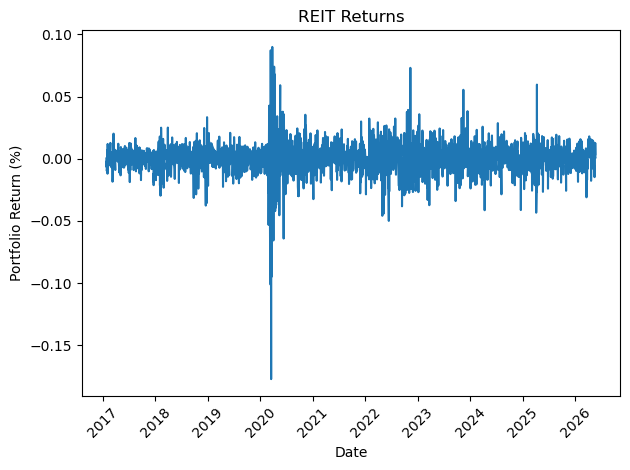

The Sharpe Ratio for the REIT portfolio
comes to 0.016


In [12]:
reit_returns = reit_close_price.pct_change().dropna()

reit_cov_matrix = reit_returns.cov()

reit_weights = np.array([1])   # same order as columns
reit_portfolio_returns = reit_returns.dot(reit_weights)
sharpe = reit_portfolio_returns.mean() /(reit_portfolio_returns.std())

returns['port_returns'] = reit_portfolio_returns

sns.lineplot(data=returns, x='date', y='port_returns')
plt.xlabel('Date')
plt.ylabel('Portfolio Return (%)')
plt.title("REIT Returns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"The Sharpe Ratio for the REIT portfolio\ncomes to {sharpe.round(3)}")

## Final Portfolio
- The last one will track Consumer Staples, or Fast Moving Consumer Goods **(FMCG)**
- This tracks groceries, branded consumer goods, and food and beverage companies
- Groceries
  * Walmart
  * Costco
  * Target
- Branded Consumer Goods
  * Procter & Gamble
  * Unilever
  * Kimberly-Clark
- Food and Beverage Companies
  * Coca-Cola
  * PepsiCo
  * Nestle
  * General Mills

In [13]:
fmcg = tf.download_data(
    domain="stock_prices",
    symbols=["WMT", "COST","TGT","PG","UL","KMB","KO","PEP","NSRGY","GIS"],
    start_date="2000-01-01",
    end_date="2026-05-26"
)
fmcg.head().round(3)

,symbol,date,volume,open,low,high,close,adjusted_close
0,WMT,2000-01-03,25109700,22.792,21.833,23.000,22.271,14.155
1,WMT,2000-01-04,20235300,21.833,21.396,21.938,21.438,13.625
2,WMT,2000-01-05,21056100,21.292,20.729,21.458,21.000,13.347
3,WMT,2000-01-06,19633500,21.000,20.896,21.521,21.229,13.492
4,WMT,2000-01-07,23930700,21.500,21.500,22.979,22.833,14.512


In [14]:
fmcg_close_price = fmcg.pivot(
    index='date',
    columns='symbol',
    values='close'
)
fmcg_close_price.tail().round(4)

symbol,COST,GIS,KMB,KO,NSRGY,PEP,PG,TGT,UL,WMT
date,,,,,,,,,,
2026-05-18,1076.4700,33.45,96.54,81.20,100.27,149.06,142.39,123.40,57.30,133.34
2026-05-19,1094.3199,33.77,96.47,81.92,100.85,150.37,141.30,127.24,57.22,134.20
2026-05-20,1074.0100,33.62,97.55,81.55,99.75,149.29,142.44,122.33,57.68,130.85
2026-05-21,1050.4500,33.47,98.73,81.17,100.71,148.85,143.40,126.15,57.72,121.34
2026-05-22,1028.2400,33.69,99.14,81.48,100.55,150.57,144.44,125.60,57.35,120.27


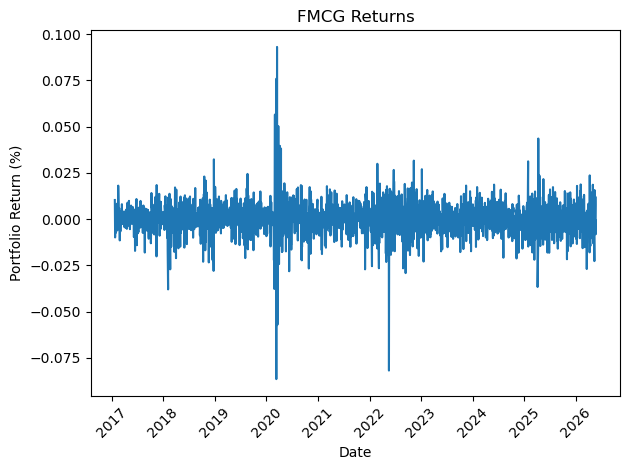

The Sharpe Ratio for the FMCG portfolio
comes to 0.033


In [15]:
fmcg_returns = fmcg_close_price.pct_change().dropna()

fmcg_cov_matrix = fmcg_returns.cov()

fmcg_weights = np.array([0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1])   # same order as columns
fmcg_portfolio_returns = fmcg_returns.dot(fmcg_weights)
sharpe = fmcg_portfolio_returns.mean() /(fmcg_portfolio_returns.std())

returns['port_returns'] = fmcg_portfolio_returns

sns.lineplot(data=returns, x='date', y='port_returns')
plt.xlabel('Date')
plt.ylabel('Portfolio Return (%)')
plt.title("FMCG Returns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"The Sharpe Ratio for the FMCG portfolio\ncomes to {sharpe.round(3)}")